In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

In [2]:
from dstparser import parse_dst_file
from pathlib import Path
dst_dir = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo"
dst_file = Path(dst_dir)/"DAT000010_gea.rufldf.dst.gz"
data = parse_dst_file(dst_file)

In [3]:
for key in data:
    print(f"{key} {data[key].shape} {data[key].dtype}")

print(f"num_fields = {len(data)}")    

mass_number (187,) int32
energy (187,) float32
shower_axis (187, 3) float32
shower_core (187, 3) float32
std_recon_yymmdd (187,) float32
std_recon_hhmmss (187,) float32
std_recon_usec (187,) float32
std_recon_nofwf (187,) float32
std_recon_nsd (187,) float32
std_recon_nsclust (187,) float32
std_recon_nhits (187,) float32
std_recon_nborder (187,) float32
std_recon_qtot (187, 2) float32
std_recon_energy (187,) float32
std_recon_ldf_scale (187,) float32
std_recon_ldf_scale_err (187,) float32
std_recon_ldf_chi2 (187,) float32
std_recon_ldf_ndof (187,) float32
std_recon_shower_core (187, 2) float32
std_recon_shower_core_err (187, 2) float32
std_recon_s800 (187,) float32
std_recon_combined_energy (187,) float32
std_recon_combined_scale (187,) float32
std_recon_combined_scale_err (187,) float32
std_recon_combined_chi2 (187,) float32
std_recon_combined_ndof (187,) float32
std_recon_combined_shower_core (187, 2) float32
std_recon_combined_shower_core_err (187, 2) float32
std_recon_combined_s800

In [4]:
from dstparser.read_data import print_data_info
print_data_info(data)

mass_number.shape=(187,), dtype=int32, size=0.001 MB
energy.shape=(187,), dtype=float32, size=0.001 MB
shower_axis.shape=(187, 3), dtype=float32, size=0.002 MB
shower_core.shape=(187, 3), dtype=float32, size=0.002 MB
std_recon_yymmdd.shape=(187,), dtype=float32, size=0.001 MB
std_recon_hhmmss.shape=(187,), dtype=float32, size=0.001 MB
std_recon_usec.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nofwf.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nsd.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nsclust.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nhits.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nborder.shape=(187,), dtype=float32, size=0.001 MB
std_recon_qtot.shape=(187, 2), dtype=float32, size=0.001 MB
std_recon_energy.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_scale.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_scale_err.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_chi2.shape=(187,), dtype=float32, size=0.001

In [5]:
for key in data:
    if not key.startswith("std_recon"):
        print(f"{key} {data[key].shape} {data[key].dtype}")

mass_number (187,) int32
energy (187,) float32
shower_axis (187, 3) float32
shower_core (187, 3) float32
detector_positions (187, 7, 7, 3) float32
detector_positions_abs (187, 7, 7, 3) float32
detector_positions_id (187, 7, 7) float32
detector_states (187, 7, 7) bool
detector_exists (187, 7, 7) bool
detector_good (187, 7, 7) bool
nfold (187, 7, 7) float32
arrival_times (187, 7, 7) float32
time_traces (187, 7, 7, 128) float32
total_signals (187, 7, 7) float32


In [6]:
from dstparser.std_qcuts import std_spectrum_quality_cuts
qcut_mask = std_spectrum_quality_cuts(data)
qdata = {key : data[key][qcut_mask] for key in data}

Total = 187
cut                 : efficiency,  combined,      after cut
-----------------------------------------------------------
nsd                 :    96.26%,    96.26%,            180
zenith              :   100.00%,    96.26%,            180
dborder             :    75.40%,    74.33%,            139
tshape_border       :    98.93%,    73.26%,            137
point_dir           :    89.30%,    72.73%,            136
chi2_geom           :    98.40%,    72.73%,            136
chi2_ldf            :    94.65%,    72.19%,            135
s800_err            :    86.10%,    72.19%,            135


In [7]:
data = parse_dst_file(dst_file, ntile = 11, add_standard_recon=False, add_shower_params=False)

In [8]:
# This fails as standard reconstruction fields are not loaded
qcut_mask = std_spectrum_quality_cuts(data)

KeyError: 'std_recon_nsd'

In [10]:
for key in data:
    print(f"{key} {data[key].shape} {data[key].dtype}")
    
detector_fields = list(data.keys())    

detector_positions (187, 11, 11, 3) float32
detector_positions_abs (187, 11, 11, 3) float32
detector_positions_id (187, 11, 11) float32
detector_states (187, 11, 11) bool
detector_exists (187, 11, 11) bool
detector_good (187, 11, 11) bool
nfold (187, 11, 11) float32
arrival_times (187, 11, 11) float32
time_traces (187, 11, 11, 128) float32
total_signals (187, 11, 11) float32


In [11]:
data = parse_dst_file(dst_file, ntile = 11, add_standard_recon=False)
for key in data:
    if key not in detector_fields:
        print(f"{key} {data[key].shape} {data[key].dtype}")  

mass_number (187,) int32
energy (187,) float32
shower_axis (187, 3) float32
shower_core (187, 3) float32


In [12]:
from dstparser.xmax_reader import XmaxReader
xmax_reader = XmaxReader(data_dir=dst_dir, glob_pattern="**/DAT*_xmax.txt", model="QGSJetII-04")

In [14]:
data = parse_dst_file(
    dst_file, ntile=11, add_standard_recon=False, xmax_reader=XmaxReader(dst_dir)
)

In [15]:
for key in data:
    if key not in detector_fields:
        print(f"{key} {data[key].shape} {data[key].dtype}")  

mass_number (187,) int32
energy (187,) float32
xmax (187,) float64
shower_axis (187, 3) float32
shower_core (187, 3) float32


In [16]:
data1 = parse_dst_file(dst_file, xmax_reader=XmaxReader(dst_dir, model="EPOS-LHC"))

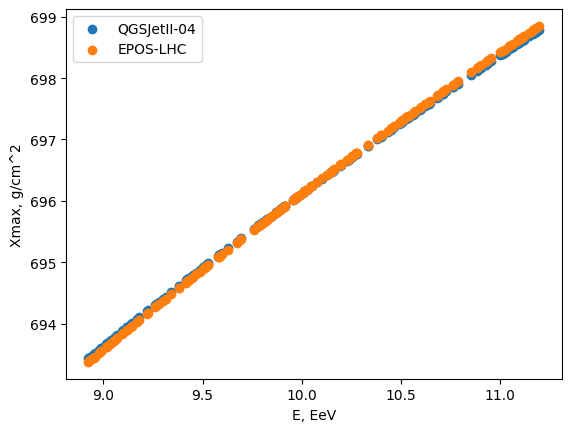

In [17]:
import matplotlib.pyplot as plt

data = parse_dst_file(dst_file, xmax_reader=XmaxReader(dst_dir, model="QGSJetII-04"))
plt.scatter(data["energy"], data["xmax"], label = "QGSJetII-04")
data = parse_dst_file(dst_file, xmax_reader=XmaxReader(dst_dir, model="EPOS-LHC"))
plt.scatter(data1["energy"], data1["xmax"], label = "EPOS-LHC")
plt.xlabel("E, EeV")
plt.ylabel("Xmax, g/cm^2")
plt.legend()

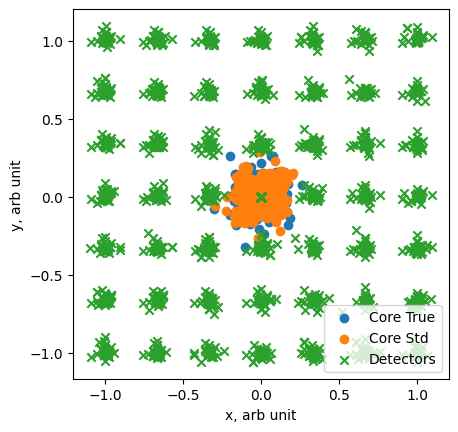

In [18]:
data = parse_dst_file(dst_file)
plt.scatter(data["shower_core"][:, 0], data["shower_core"][:, 1], label="Core True")
plt.scatter(data["std_recon_shower_core"][:, 0], data["std_recon_shower_core"][:, 1], label="Core Std")
plt.scatter(data["detector_positions"][..., 0], data["detector_positions"][..., 1], marker="x", label="Detectors")
plt.xlabel("x, arb unit")
plt.ylabel("y, arb unit")
plt.gca().set_aspect("equal")
plt.legend()

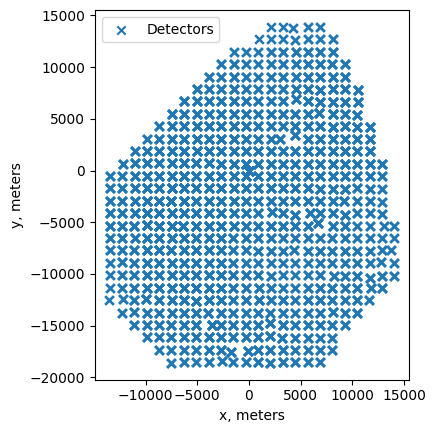

In [19]:
plt.scatter(data["detector_positions_abs"][..., 0], data["detector_positions_abs"][..., 1], marker="x", label="Detectors")
plt.xlabel("x, meters")
plt.ylabel("y, meters")
plt.gca().set_aspect("equal")
plt.legend()

In [ ]:
# TAx4 and TA files have slight difference
# parse_dst_file_tax4 reads TAx4 file and has the same functionality as parse_dst_file

# This fails as we have dst files for TA 
from dstparser import parse_dst_file_tax4
data = parse_dst_file_tax4(dst_file)

IndexError: index 0 is out of bounds for axis 0 with size 0

In [75]:
glob_pattern = "DAT*dst.gz"
# Search for data files
data_files = sorted([str(file) for file in Path(dst_dir).rglob(glob_pattern)])
print(f"Number of found data files = {len(data_files)}")

Number of found data files = 33000


In [76]:
from dstparser.read_data import print_data_info

In [77]:
print_data_info(data)

mass_number.shape=(187,), dtype=int32, size=0.001 MB
energy.shape=(187,), dtype=float32, size=0.001 MB
shower_axis.shape=(187, 3), dtype=float32, size=0.002 MB
shower_core.shape=(187, 3), dtype=float32, size=0.002 MB
std_recon_yymmdd.shape=(187,), dtype=float32, size=0.001 MB
std_recon_hhmmss.shape=(187,), dtype=float32, size=0.001 MB
std_recon_usec.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nofwf.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nsd.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nsclust.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nhits.shape=(187,), dtype=float32, size=0.001 MB
std_recon_nborder.shape=(187,), dtype=float32, size=0.001 MB
std_recon_qtot.shape=(187, 2), dtype=float32, size=0.001 MB
std_recon_energy.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_scale.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_scale_err.shape=(187,), dtype=float32, size=0.001 MB
std_recon_ldf_chi2.shape=(187,), dtype=float32, size=0.001

In [59]:
data["detector_positions"].shape

(187, 7, 7, 3)

In [10]:
# Set directory to search for dst files
data_dir = "/ceph/work/SATORI/antonpr/ml/benMC/sdanalysis_2019"
# and pattern of dst files names
glob_pattern = "DAT*dst.gz"
# Search for data files
data_files = sorted([str(file) for file in Path(data_dir).glob(glob_pattern)])
print(f"Number of found data files = {len(data_files)}")

Number of found data files = 7


In [7]:
for field_name in data:
    print(
        f"{field_name}{data[field_name].shape}"
    )

mass_number(224,)
energy(224,)
shower_axis(224, 3)
shower_core(224, 3)
std_recon_yymmdd(224,)
std_recon_hhmmss(224,)
std_recon_usec(224,)
std_recon_nofwf(224,)
std_recon_nsd(224,)
std_recon_nsclust(224,)
std_recon_nhits(224,)
std_recon_nborder(224,)
std_recon_qtot(224, 2)
std_recon_energy(224,)
std_recon_ldf_scale(224,)
std_recon_ldf_scale_err(224,)
std_recon_ldf_chi2(224,)
std_recon_ldf_ndof(224,)
std_recon_shower_core(224, 2)
std_recon_shower_core_err(224, 2)
std_recon_s800(224,)
std_recon_combined_energy(224,)
std_recon_combined_scale(224,)
std_recon_combined_scale_err(224,)
std_recon_combined_chi2(224,)
std_recon_combined_ndof(224,)
std_recon_combined_shower_core(224, 2)
std_recon_combined_shower_core_err(224, 2)
std_recon_combined_s800(224,)
std_recon_shower_axis(224, 3)
std_recon_shower_axis_fixed_curve(224, 3)
std_recon_shower_axis_combined(224, 3)
std_recon_shower_axis_err(224,)
std_recon_shower_axis_err_fixed_curve(224,)
std_recon_shower_axis_err_combined(224,)
std_recon_geom_

In [ ]:
import numpy as np
from dstparser import parse_dst_file, parse_dst_file_tax4
from time import time
from dstparser.cli.cli import parse_config
import sys


def test_parser(dst_file, print_read_data=False, use_ta_x4=False, add_xmax=False):

    if len(sys.argv) > 1:
        config = parse_config(sys.argv[1])
    else:
        config = None
    start = time()

    # The only function that are required to parsing
    # is parse_dst_file
    # paths to the directories with data is dstparser.paths module
    # data = parse_dst_file(dst_file, up_low_traces=True)

    if use_ta_x4:
        convert_func = parse_dst_file_tax4
    else:
        convert_func = parse_dst_file

    if add_xmax:
        from dstparser.xmax_reader import XmaxReader

        xmax_dir = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo"
        xmax_reader = XmaxReader(xmax_dir, "**/DAT*_xmax.txt", "QGSJetII-04")
    else:
        xmax_reader = None

    data = convert_func(
        dst_file,
        ntile=7,
        xmax_reader=xmax_reader,
        avg_traces=False,
        add_shower_params=True,
        add_standard_recon=True,
        config=config,
    )

    end = time()

    if print_read_data:
        print(f"\nConverted arrays:\n---")
        for key, val in data.items():
            if isinstance(val, np.ndarray):
                print(key, val.shape)
            else:
                print(key, len(val), val)

    # print(f'energy = {data["energy"]}')
    # print(f'xmax = {data["xmax"]}')
    # print(f'time_traces_low = {data["time_traces_low"]}')
    # print(f'event id = {data["event_id"]}')
    # print(f'corsika shower id = {data["corsika_shower_id"]}')
    # print(f'energy bin id = {data["energy_bin_id"]}')
    # print(f"detector_positions_id = {data['detector_positions_id'][50]}")
    # print(f"detector_positions_abs = {data['detector_positions_abs'][50][:, :, 0]}")
    # print(f"detector_positions = {data['detector_positions'][50][:, :, 0].astype(np.float16)}")
    # print(f"detector_positions_id = {data['detector_positions_abs'][50].shape}")
    # print("xmax=", data["xmax"])
    if config is not None:
        print(f'event_id = {data["id_event"]}')
        print(f'corsika_shower_id = {data["id_corsika_shower"]}')
        print(f'energy_bin_id = {data["id_energy_bin"]}')
        print(f'data_set_id = {data["id_data_set"]}')

    print("----")
    print(f"Parse time: {end - start:.3f} sec")


if __name__ == "__main__":
    # dst_file = (
    #     "/ceph/work/SATORI/projects/TA-ASIoP/INR_group/cluster82/grisha/tasdmc_SIBYLL_fe/p2/"
    #     "DAT013520.corsika77420.SIBYLL.tar.gz.spctr1.1945.noCuts.dst.gz"
    # )
    # dst_file = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo/DAT055402_gea.rufldf.dst.gz"
    dst_file = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04proton/080417_160603/Em1_bsdinfo/DAT051419_gea.rufldf.dst.gz"
    # dst_file = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/tax4/qgsii04proton/north/221101to240124/DAT010019_gea.rufldf.dst.gz"

    # dst_file = "/ceph/work/SATORI/projects/TA-ASIoP/tasdmc_dstbank/qgsii04nitrogen/080417_160603/Em1_bsdinfo/DAT081325_gea.rufldf.dst.gz"
    # !If you want to use TAx4 format, set use_ta_x4=True
    # !If you want to use TA format, set use_ta_x4=False
    # !By default, use_ta_x4=False
    test_parser(dst_file, print_read_data=True, use_ta_x4=False, add_xmax=False)
